In [ ]:
from photutils.psf import CircularGaussianSigmaPRF
from photutils.psf_matching import make_kernel, make_wiener_kernel
 
import os
import os.path
import glob
import numpy as np
from tqdm import tqdm
import math
import warnings
import argparse

#Numpy,matplotlib,etc.
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image

#Astropy
#from astropy.visualization import ZScaleInterval
from astropy.io import fits
from scipy.ndimage import shift
from astropy.stats import mad_std
from astropy.stats import sigma_clip
from astropy.modeling import models, fitting
import photutils.psf_matching as psf
from photutils.utils import calc_total_error
import astropy.stats as stat
from photutils.aperture import aperture_photometry, ApertureStats, CircularAperture, CircularAnnulus
from photutils.detection import DAOStarFinder
import astropy
from photutils.profiles import CurveOfGrowth

import matplotlib.cm as cm
import scipy.signal
import time
import shutil
import scipy.signal
from skimage.registration import phase_cross_correlation
from scipy.ndimage import gaussian_filter

from astropy.visualization import SimpleNorm
from scipy.signal import fftconvolve



In [7]:
def get_psf(target_image,star_bound,background_bound,size):
    '''
    This function takes the centroid of the area specified in a reference image (intended to be one star), 
    then takes the centroid of the same area in the specified list of images, 
    and calculates the shifts required to map them to the reference image.
    Inputs:
    ref_image (str): the filepath of the reference image
    target_image (str): the filepath of the target image
    star_bound (np array): the bounds for the box of which to centroid, in [[xmin,xmax],[ymin,ymax]] form
    background_bound (np array): the bounds for the box of which to calculate the background from, in [[xmin,xmax],[ymin,ymax]] form
    Outputs:
    xy_shift (list): the x and y shifts for the target image
    '''
    
    #Calculate the shifts as compared to the reference centroid
    
    #Set our sum arrays to nothing
    img_x_weight = []
    img_y_weight = []
    img_no_weight = []
        
    #Converting the fits to a np.array
    img_fits = fits.getdata(target_image)

    #Extracing star+background patches
    img_background = img_fits[background_bound[1][0]:background_bound[1][1],background_bound[0][0]:background_bound[0][1]]
    img_star = img_fits[star_bound[1][0]:star_bound[1][1],star_bound[0][0]:star_bound[0][1]]
        
    #Calculating the background
    img_median = np.median(img_background)
        
    #Nested for loops for x/y weighted pixels
    for x in np.arange(0,img_star.shape[1]):
        for y in np.arange(0,img_star.shape[0]):
            img_x_weight.append((img_star[x,y]-img_median)*x)
            img_y_weight.append((img_star[x,y]-img_median)*y)
            img_no_weight.append(img_star[x,y]-img_median)
                
    #Calculate the image's centroid
    img_x_centroid = sum(img_x_weight)/sum(img_no_weight)
    img_y_centroid = sum(img_y_weight)/sum(img_no_weight)
    img_centroid = [img_x_centroid,img_y_centroid]
    starbox = img_star[int(img_x_centroid)-size:int(img_x_centroid)+size+1, int(img_y_centroid)-size:int(img_y_centroid)+size+1]


    y, x, = np.mgrid[:size*2+1, :size*2+1]
    f_init = models.Gaussian2D(amplitude = starbox[int(img_x_centroid),int(img_y_centroid)]-np.median(img_background),x_mean=int(img_x_centroid), y_mean = int(img_y_centroid))
    fit_f = fitting.LevMarLSQFitter()

    f = fit_f(f_init, x, y, starbox-np.median(img_background))

    psf_fin = f(x,y)/np.sum(f(x,y))


    return img_centroid, psf_fin, starbox
        
    # #Calculate the x/y shifts, print them, and add them to the list
    # x_shift = ref_centroid[0] - img_centroid[0]
    # y_shift = ref_centroid[1] - img_centroid[1]
    # xy_shift = [x_shift,y_shift]
    # return xy_shift

In [8]:
name1 = "/Users/samkleiman/Desktop/PERKINS_DATA_TESTING/20250319/standard/HaON/registered_New H Alpha (On).fits"
name2 = "/Users/samkleiman/Desktop/PERKINS_DATA_TESTING/20250319/standard/HaOFF/registered_New H Alpha (Off).fits"
name3 = "/Users/samkleiman/Desktop/PERKINS_DATA_TESTING/20250319/standard/B/registered_B.fits"

In [9]:
star_bound = [[925,1025],[968,1068]]
bg_bound = [[900,1000],[850,950]]

In [10]:
cent1, psf1, starbox1 = get_psf(name1, star_bound, bg_bound,40)
cent2, psf2, starbox2 = get_psf(name2, star_bound, bg_bound,40)

#kernel1 = make_kernel(psf1,psf2)
kernellap = make_wiener_kernel(psf1,psf2, penalty="laplacian", regularization=1e-5) #1e-5 works! Keep messing around with penalty and regularization. (make a loop to try variety of values per image?)
kernel2 = make_wiener_kernel(psf1,psf2)

match1 = fftconvolve(psf1,kernellap,mode='same')
match2 = fftconvolve(psf1,kernel2,mode='same')

In [11]:
for i in np.arange(1,11):
    kernellap = make_wiener_kernel(psf1,psf2, penalty="laplacian", regularization=i*1e-6) #1e-5 works! Keep messing around with penalty and regularization. (make a loop to try variety of values per image?)
    kernel2 = make_wiener_kernel(psf1,psf2)

    match1 = fftconvolve(psf1,kernellap,mode='same')
    match2 = fftconvolve(psf1,kernel2,mode='same')

    plt.figure(figsize=(20,6))
    plt.subplot(2, 4, 1)
    plt.imshow(psf1)
    plt.colorbar()
    plt.title("psf_1")
    plt.subplot(2, 4, 2)
    plt.imshow(match1)
    plt.colorbar()
    plt.title(f' {i} $$*10^{-6}$$ Penalty')
    plt.subplot(2,4,3)
    plt.imshow(match2)
    plt.colorbar()
    plt.title("no penalty")
    plt.subplot(2,4,4)
    plt.imshow(psf2)
    plt.colorbar()
    plt.title("psf_2")
    plt.subplot(2, 4, 5)
    plt.imshow(psf2,vmin=-.0003,vmax=.0006)
    plt.colorbar()
    plt.title("psf")
    plt.subplot(2, 4, 6)
    plt.imshow(psf2-match1,vmin=-.0003,vmax=.0006)
    plt.colorbar()
    plt.title(f' {i} $$*10^{-6}$$ Penalty')
    plt.subplot(2,4,7)
    plt.imshow(psf2-match2,vmin=-.0003,vmax=.0006)
    plt.colorbar()
    plt.title("no penalty")
    plt.subplot(2,4,8)
    plt.imshow(psf2-psf1)
    plt.colorbar()
    plt.title("unmatched")

    xycen = (40.0, 40.0)
    radii = np.arange(1, 40)

    cog_ch1 = CurveOfGrowth(psf1, xycen, radii)
    cog_ch4 = CurveOfGrowth(psf2, xycen, radii)
    cog_m1 = CurveOfGrowth(match1, xycen, radii)
    cog_m2 = CurveOfGrowth(match2, xycen, radii)


    for cog in [cog_ch1, cog_ch4, cog_m1, cog_m2]:
        cog.normalize()

    labels = [
        f' {i} $$*10^{-6}$$ Penalty',
        'No Penalty'
    ]
    cogs_matched = [cog_m1, cog_m2]
    ls_list = ['--', '-.']

    fig, (ax_top, ax_bot) = plt.subplots(
        nrows=2, figsize=(8, 8),
        gridspec_kw={'height_ratios': [3, 1]},
        sharex=True,
    )

    # Main panel
    cog_ch1.plot(ax=ax_top, label='HaON PSF', lw=2,
                color='C0', ls='-')
    cog_ch4.plot(ax=ax_top, label='HaOFF PSF', lw=3,
                color='k')
    for cog, label, ls in zip(cogs_matched, labels, ls_list):
        cog.plot(ax=ax_top, label=label, lw=2, ls=ls)
    ax_top.set_ylabel('Normalized Encircled Energy')
    ax_top.set_title(
        'Encircled Energy: Ha ON & OFF PSFs vs. PSF-matched results')
    ax_top.legend(fontsize=9)
    ax_top.set_xlabel('')

    # Residual subpanel (matched - ch4)
    for cog, label, ls in zip(cogs_matched, labels, ls_list):
        resid = cog.profile - cog_ch4.profile
        ax_bot.plot(cog.radius, resid, lw=2, ls=ls, label=label)
    ax_bot.axhline(0, color='k', lw=1, ls='-')
    ax_bot.set_xlabel('Radius (pixels)')
    ax_bot.set_ylabel('Residual')
    ax_bot.set_title('Matched $-$ Ha OFF')

    fig.tight_layout()


ValueError: 
 1 $$*10^-6$$ Penalty
   ^
ParseException: Expected end of text, found '$'  (at char 3), (line:1, col:4)

Error in callback <function _draw_all_if_interactive at 0x11fddc300> (for post_execute), with arguments args (),kwargs {}:


ValueError: 
 1 $$*10^-6$$ Penalty
   ^
ParseException: Expected end of text, found '$'  (at char 3), (line:1, col:4)

ValueError: 
 1 $$*10^-6$$ Penalty
   ^
ParseException: Expected end of text, found '$'  (at char 3), (line:1, col:4)

<Figure size 2000x600 with 16 Axes>

ValueError: 
 1 $$*10^-6$$ Penalty
   ^
ParseException: Expected end of text, found '$'  (at char 3), (line:1, col:4)

<Figure size 800x800 with 2 Axes>

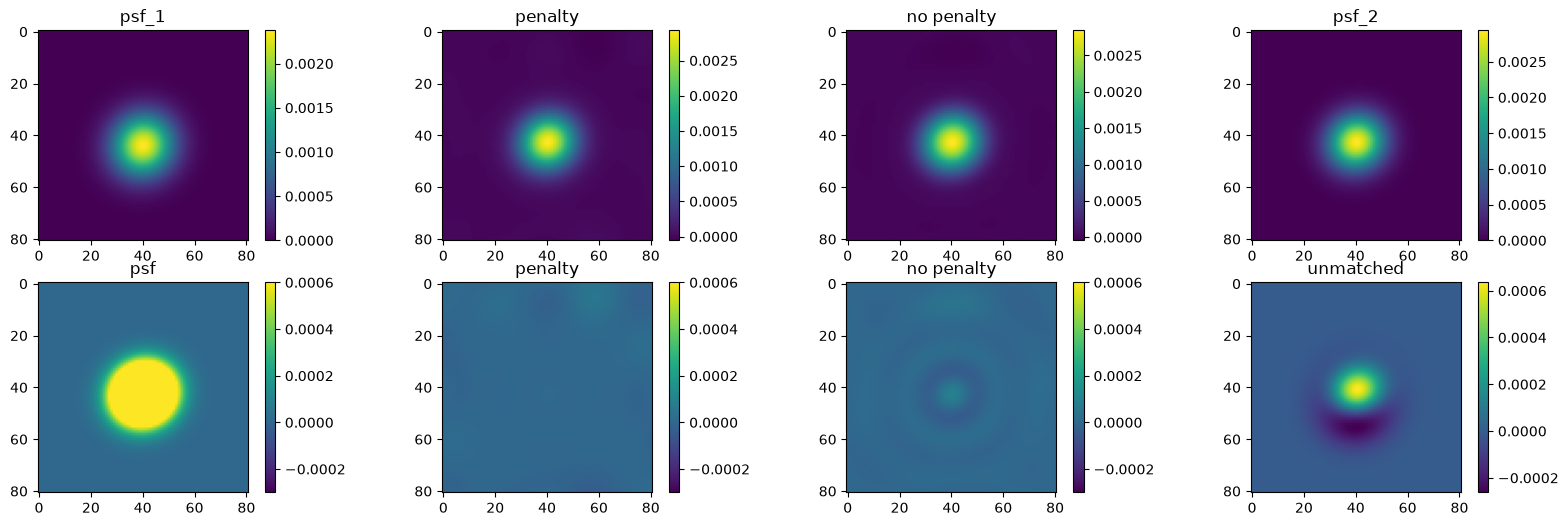

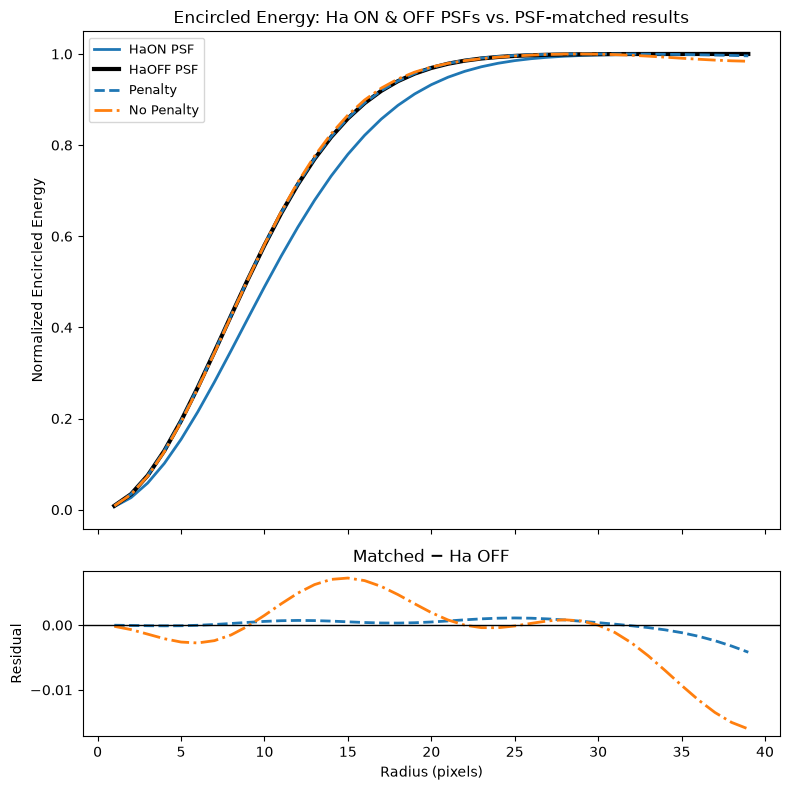

In [ ]:
plt.figure(figsize=(20,6))
plt.subplot(2, 4, 1)
plt.imshow(psf1)
plt.colorbar()
plt.title("psf_1")
plt.subplot(2, 4, 2)
plt.imshow(match1)
plt.colorbar()
plt.title("penalty")
plt.subplot(2,4,3)
plt.imshow(match2)
plt.colorbar()
plt.title("no penalty")
plt.subplot(2,4,4)
plt.imshow(psf2)
plt.colorbar()
plt.title("psf_2")
plt.subplot(2, 4, 5)
plt.imshow(psf2,vmin=-.0003,vmax=.0006)
plt.colorbar()
plt.title("psf")
plt.subplot(2, 4, 6)
plt.imshow(psf2-match1,vmin=-.0003,vmax=.0006)
plt.colorbar()
plt.title("penalty")
plt.subplot(2,4,7)
plt.imshow(psf2-match2,vmin=-.0003,vmax=.0006)
plt.colorbar()
plt.title("no penalty")
plt.subplot(2,4,8)
plt.imshow(psf2-psf1)
plt.colorbar()
plt.title("unmatched")

xycen = (40.0, 40.0)
radii = np.arange(1, 40)

cog_ch1 = CurveOfGrowth(psf1, xycen, radii)
cog_ch4 = CurveOfGrowth(psf2, xycen, radii)
cog_m1 = CurveOfGrowth(match1, xycen, radii)
cog_m2 = CurveOfGrowth(match2, xycen, radii)


for cog in [cog_ch1, cog_ch4, cog_m1, cog_m2]:
    cog.normalize()

labels = [
    'Penalty',
    'No Penalty'
]
cogs_matched = [cog_m1, cog_m2]
ls_list = ['--', '-.']

fig, (ax_top, ax_bot) = plt.subplots(
    nrows=2, figsize=(8, 8),
    gridspec_kw={'height_ratios': [3, 1]},
    sharex=True,
)

# Main panel
cog_ch1.plot(ax=ax_top, label='HaON PSF', lw=2,
             color='C0', ls='-')
cog_ch4.plot(ax=ax_top, label='HaOFF PSF', lw=3,
             color='k')
for cog, label, ls in zip(cogs_matched, labels, ls_list):
    cog.plot(ax=ax_top, label=label, lw=2, ls=ls)
ax_top.set_ylabel('Normalized Encircled Energy')
ax_top.set_title(
    'Encircled Energy: Ha ON & OFF PSFs vs. PSF-matched results')
ax_top.legend(fontsize=9)
ax_top.set_xlabel('')

# Residual subpanel (matched - ch4)
for cog, label, ls in zip(cogs_matched, labels, ls_list):
    resid = cog.profile - cog_ch4.profile
    ax_bot.plot(cog.radius, resid, lw=2, ls=ls, label=label)
ax_bot.axhline(0, color='k', lw=1, ls='-')
ax_bot.set_xlabel('Radius (pixels)')
ax_bot.set_ylabel('Residual')
ax_bot.set_title('Matched $-$ Ha OFF')

fig.tight_layout()


Text(0.5, 1.0, 'unmatched')

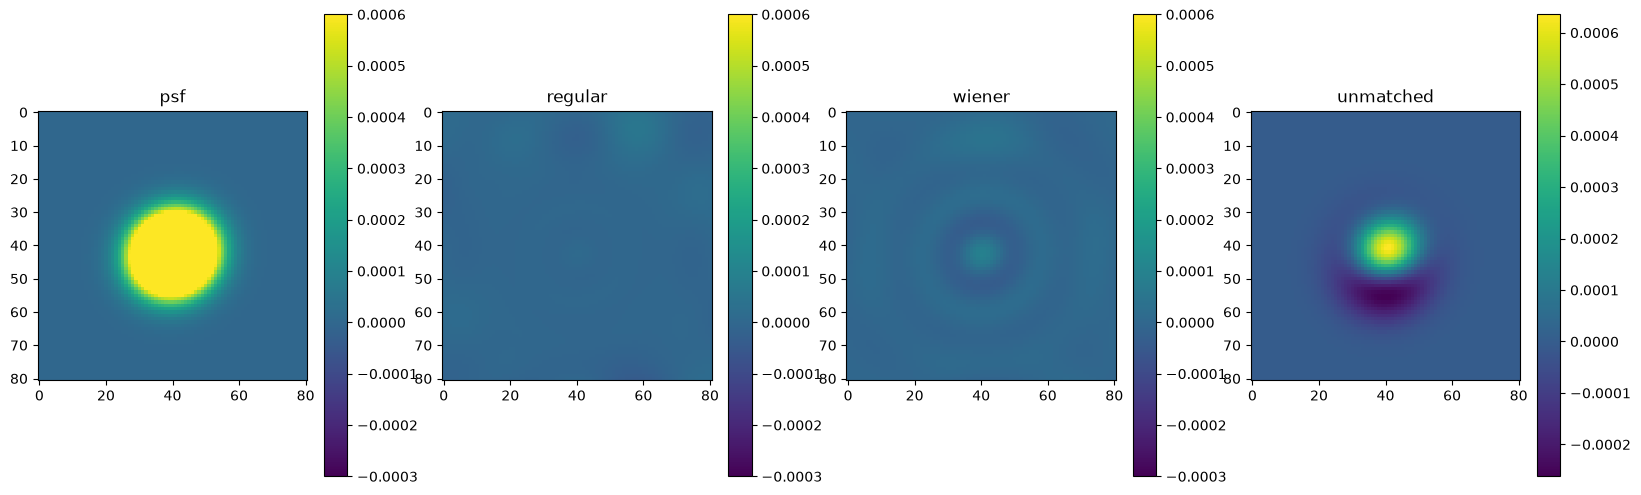

In [ ]:
plt.figure(figsize=(20,6))
plt.subplot(1, 4, 1)
plt.imshow(psf2,vmin=-.0003,vmax=.0006)
plt.colorbar()
plt.title("psf")
plt.subplot(1, 4, 2)
plt.imshow(psf2-match1,vmin=-.0003,vmax=.0006)
plt.colorbar()
plt.title("regular")
plt.subplot(1,4,3)
plt.imshow(psf2-match2,vmin=-.0003,vmax=.0006)
plt.colorbar()
plt.title("wiener")
plt.subplot(1,4,4)
plt.imshow(psf2-psf1)
plt.colorbar()
plt.title("unmatched")

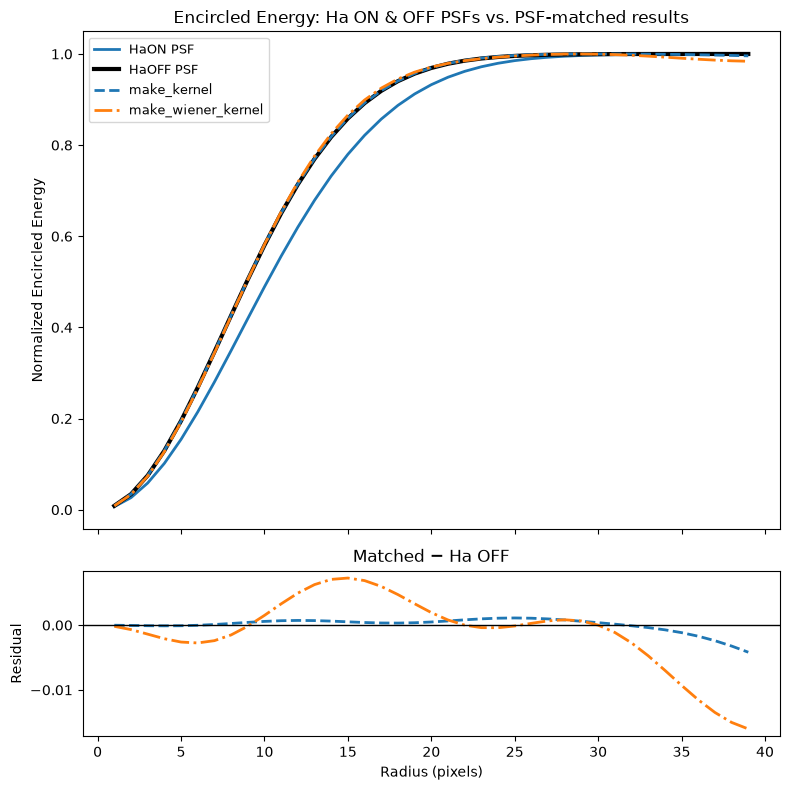

In [ ]:
xycen = (40.0, 40.0)
radii = np.arange(1, 40)

cog_ch1 = CurveOfGrowth(psf1, xycen, radii)
cog_ch4 = CurveOfGrowth(psf2, xycen, radii)
cog_m1 = CurveOfGrowth(match1, xycen, radii)
cog_m2 = CurveOfGrowth(match2, xycen, radii)


for cog in [cog_ch1, cog_ch4, cog_m1, cog_m2]:
    cog.normalize()

labels = [
    'make_kernel',
    'make_wiener_kernel'
]
cogs_matched = [cog_m1, cog_m2]
ls_list = ['--', '-.']

fig, (ax_top, ax_bot) = plt.subplots(
    nrows=2, figsize=(8, 8),
    gridspec_kw={'height_ratios': [3, 1]},
    sharex=True,
)

# Main panel
cog_ch1.plot(ax=ax_top, label='HaON PSF', lw=2,
             color='C0', ls='-')
cog_ch4.plot(ax=ax_top, label='HaOFF PSF', lw=3,
             color='k')
for cog, label, ls in zip(cogs_matched, labels, ls_list):
    cog.plot(ax=ax_top, label=label, lw=2, ls=ls)
ax_top.set_ylabel('Normalized Encircled Energy')
ax_top.set_title(
    'Encircled Energy: Ha ON & OFF PSFs vs. PSF-matched results')
ax_top.legend(fontsize=9)
ax_top.set_xlabel('')

# Residual subpanel (matched - ch4)
for cog, label, ls in zip(cogs_matched, labels, ls_list):
    resid = cog.profile - cog_ch4.profile
    ax_bot.plot(cog.radius, resid, lw=2, ls=ls, label=label)
ax_bot.axhline(0, color='k', lw=1, ls='-')
ax_bot.set_xlabel('Radius (pixels)')
ax_bot.set_ylabel('Residual')
ax_bot.set_title('Matched $-$ Ha OFF')

fig.tight_layout()


Text(0.5, 1.0, 'Subtracted')

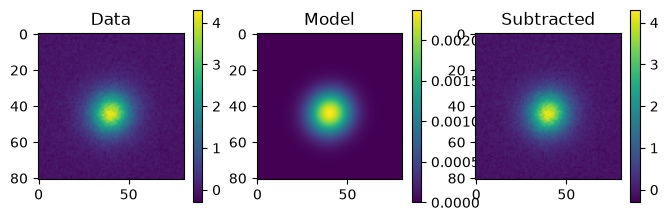

In [ ]:
plt.figure(figsize=(8, 2.5))
plt.subplot(1, 3, 1)
plt.imshow(starbox1-np.median(starbox1))
plt.colorbar()
plt.title("Data")
plt.subplot(1, 3, 2)
plt.imshow(psf1)
plt.colorbar()
plt.title("Model")
plt.subplot(1, 3, 3)
plt.imshow(starbox1-np.median(starbox1)-psf1)
plt.colorbar()
plt.title("Subtracted")

Text(0.5, 1.0, 'Model')

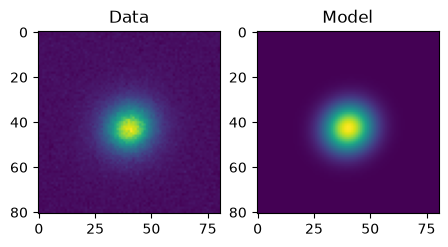

In [ ]:
plt.figure(figsize=(8, 2.5))
plt.subplot(1, 3, 1)
plt.imshow(starbox2)
plt.title("Data")
plt.subplot(1, 3, 2)
plt.imshow(psf2)
plt.title("Model")

In [ ]:
kernel1 = make_kernel(psf1,psf2)
kernel2 = make_wiener_kernel(psf1,psf2)
print(np.sum(kernel1))
print(np.sum(kernel2))



1.0000000000000007
1.0


Text(0.5, 1.0, 'make_kernel')

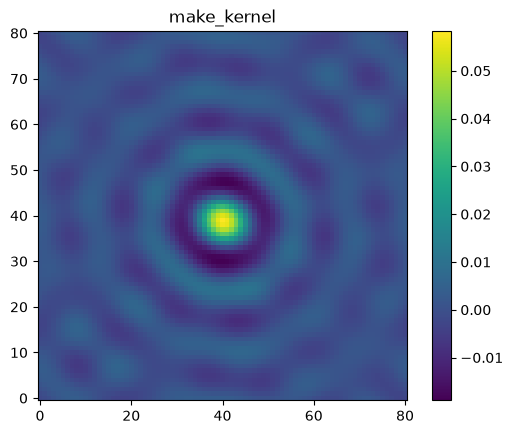

In [ ]:
plt.imshow(kernel1, origin='lower')
plt.colorbar()
plt.title('make_kernel')

Text(0.5, 1.0, 'make_wiener_kernel')

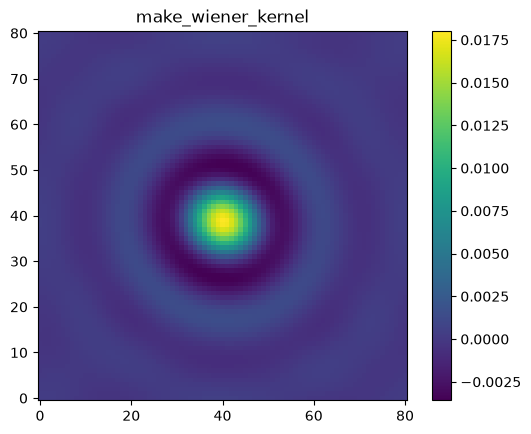

In [ ]:
plt.imshow(kernel2, origin='lower')
plt.colorbar()
plt.title('make_wiener_kernel')

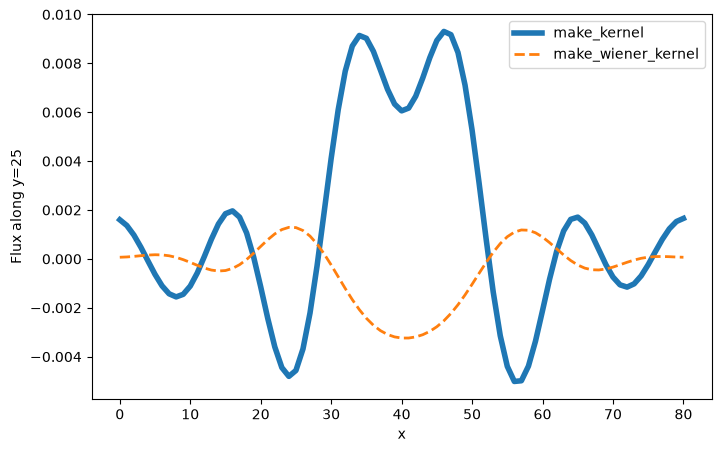

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(kernel1[25, :], label='make_kernel', lw=4)
ax.plot(kernel2[25, :], label='make_wiener_kernel', lw=2, ls='--')
ax.set_xlabel('x')
ax.set_ylabel('Flux along y=25')
ax.legend()
#ax.set_ylim((0.0, 0.011))

In [ ]:
match1 = fftconvolve(psf1,kernel1,mode='same')
match2 = fftconvolve(psf1,kernel2,mode='same')

Text(0.5, 1.0, 'psf_2')

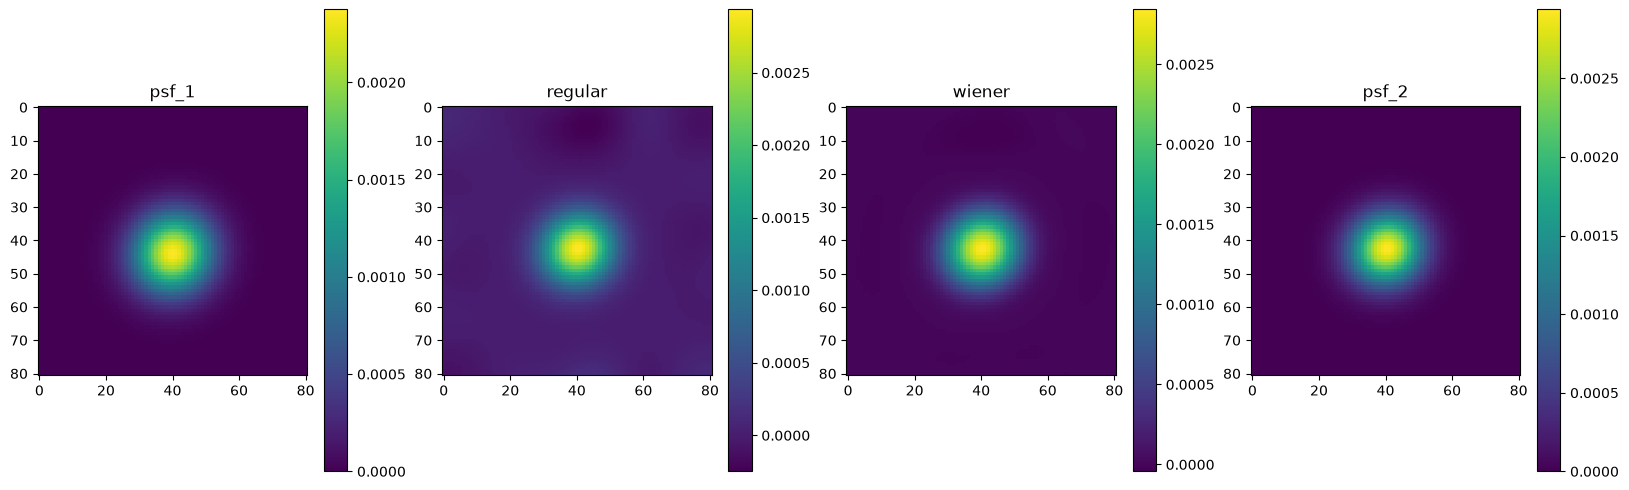

In [ ]:
plt.figure(figsize=(20,6))
plt.subplot(1, 4, 1)
plt.imshow(psf1)
plt.colorbar()
plt.title("psf_1")
plt.subplot(1, 4, 2)
plt.imshow(match1)
plt.colorbar()
plt.title("regular")
plt.subplot(1,4,3)
plt.imshow(match2)
plt.colorbar()
plt.title("wiener")
plt.subplot(1,4,4)
plt.imshow(psf2)
plt.colorbar()
plt.title("psf_2")

Text(0.5, 1.0, 'unmatched')

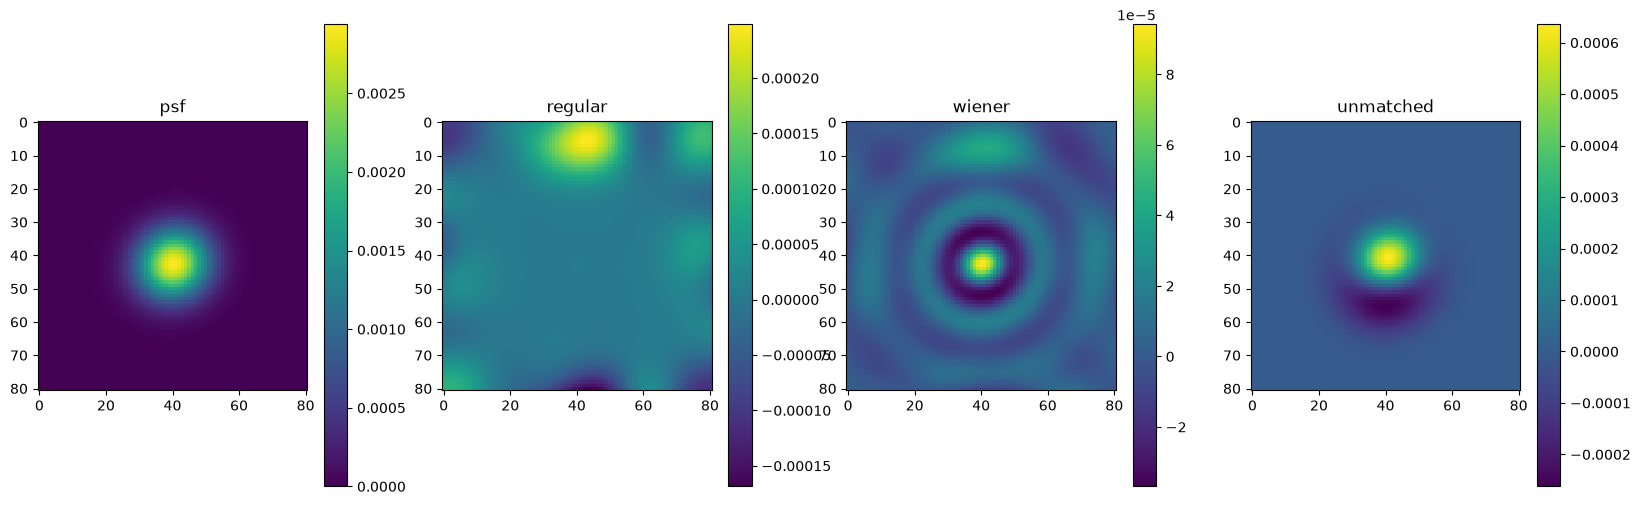

In [ ]:
plt.figure(figsize=(20,6))
plt.subplot(1, 4, 1)
plt.imshow(psf2)
plt.colorbar()
plt.title("psf")
plt.subplot(1, 4, 2)
plt.imshow(psf2-match1)
plt.colorbar()
plt.title("regular")
plt.subplot(1,4,3)
plt.imshow(psf2-match2)
plt.colorbar()
plt.title("wiener")
plt.subplot(1,4,4)
plt.imshow(psf2-psf1)
plt.colorbar()
plt.title("unmatched")

In [ ]:
type(psf1)

numpy.ndarray

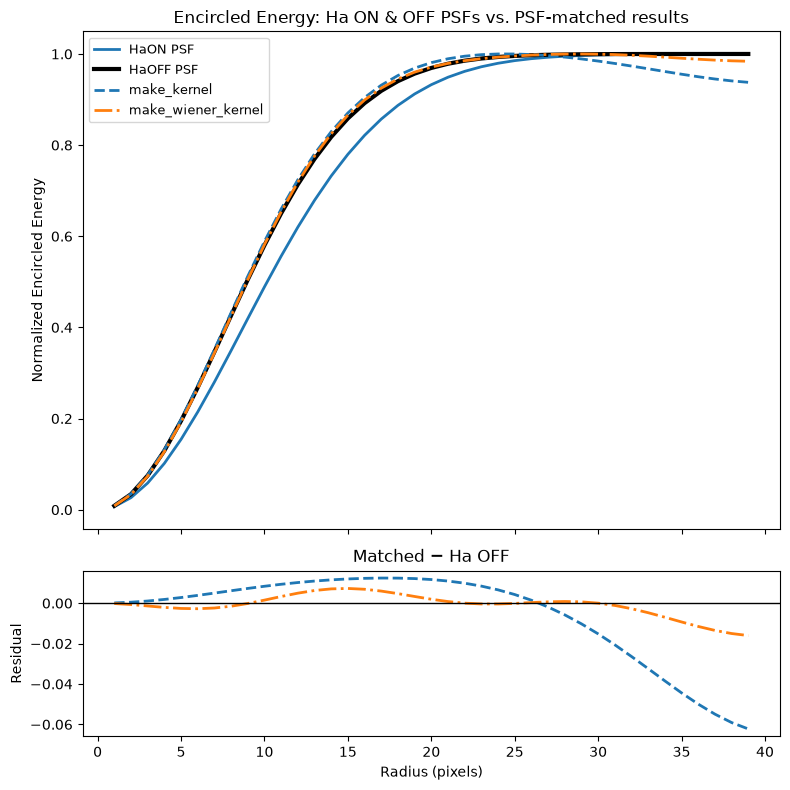

In [ ]:
xycen = (40.0, 40.0)
radii = np.arange(1, 40)

cog_ch1 = CurveOfGrowth(psf1, xycen, radii)
cog_ch4 = CurveOfGrowth(psf2, xycen, radii)
cog_m1 = CurveOfGrowth(match1, xycen, radii)
cog_m2 = CurveOfGrowth(match2, xycen, radii)


for cog in [cog_ch1, cog_ch4, cog_m1, cog_m2]:
    cog.normalize()

labels = [
    'make_kernel',
    'make_wiener_kernel'
]
cogs_matched = [cog_m1, cog_m2]
ls_list = ['--', '-.']

fig, (ax_top, ax_bot) = plt.subplots(
    nrows=2, figsize=(8, 8),
    gridspec_kw={'height_ratios': [3, 1]},
    sharex=True,
)

# Main panel
cog_ch1.plot(ax=ax_top, label='HaON PSF', lw=2,
             color='C0', ls='-')
cog_ch4.plot(ax=ax_top, label='HaOFF PSF', lw=3,
             color='k')
for cog, label, ls in zip(cogs_matched, labels, ls_list):
    cog.plot(ax=ax_top, label=label, lw=2, ls=ls)
ax_top.set_ylabel('Normalized Encircled Energy')
ax_top.set_title(
    'Encircled Energy: Ha ON & OFF PSFs vs. PSF-matched results')
ax_top.legend(fontsize=9)
ax_top.set_xlabel('')

# Residual subpanel (matched - ch4)
for cog, label, ls in zip(cogs_matched, labels, ls_list):
    resid = cog.profile - cog_ch4.profile
    ax_bot.plot(cog.radius, resid, lw=2, ls=ls, label=label)
ax_bot.axhline(0, color='k', lw=1, ls='-')
ax_bot.set_xlabel('Radius (pixels)')
ax_bot.set_ylabel('Residual')
ax_bot.set_title('Matched $-$ Ha OFF')

fig.tight_layout()
